In [22]:
cd SCOIT

/Users/fengcong/Desktop/0825-course/Guided Study/Code/SCOIT


In [19]:
pwd

'/Users/fengcong/Desktop/0825-course/Guided Study/Code'

In [20]:
import numpy as np
import pandas as pd
import time
import seaborn as sns
import hypernetx as hnx
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd
import time

from hgnn.hypergraph import load_graph, load_graph_metadata

In [23]:
df = load_graph_metadata(Path('./hypergraph'))
df.to_csv('./hypergraph/graph_metadata.csv', index=False)
df = pd.read_csv('./hypergraph/graph_metadata.csv')

Found dataset: SNARE_seq_adult_mouse
Found dataset: sc_GEM
Found dataset: CITE_seq
Found dataset: SNARE_seq_neonatal_mouse
Found dataset: SCoPE2
Found dataset: sci_CAR
Found dataset: PEA_STA


In [27]:
df.set_index('dataname').sort_values('num_nodes num_edges'.split(), ascending=True)

,num_cells,num_genes,num_omics,num_nodes,num_edges
dataname,,,,,
sc_GEM,224,61,2,287,6805
PEA_STA,210,166,2,378,9977
SNARE_seq_neonatal_mouse,5081,100,2,5183,5915
SCoPE2,1490,5314,2,6806,13239
sci_CAR,8837,100,2,8939,10358
SNARE_seq_adult_mouse,10309,100,2,10411,14504
CITE_seq,8617,36293,2,44912,4993779


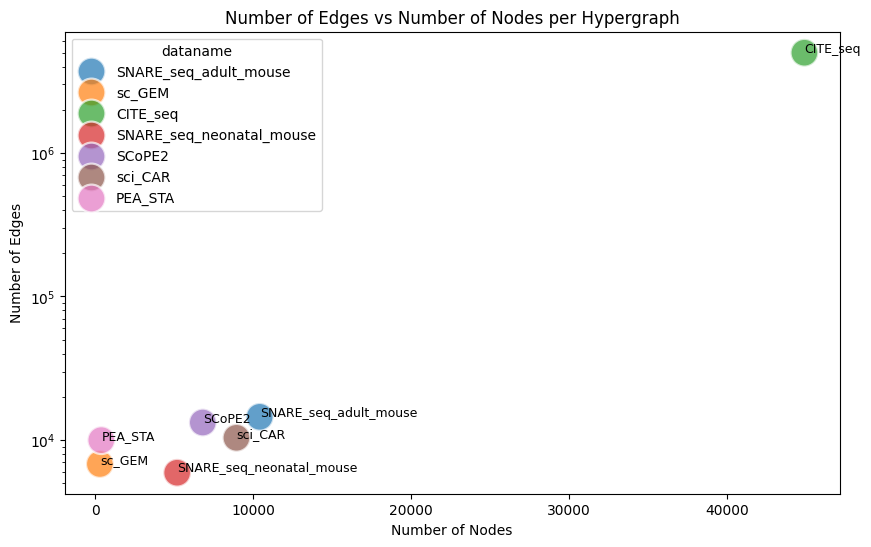

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot num_edges vs num_cells
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="num_nodes", y="num_edges", hue="dataname", s=400, alpha=0.7)
plt.yscale("log")
plt.title("Number of Edges vs Number of Nodes per Hypergraph")
plt.xlabel("Number of Nodes")
plt.ylabel("Number of Edges")

# Add text labels to each point
for idx, row in df.iterrows():
    # Place text slightly offset from the point to avoid overlap
    plt.text(
        x=row["num_nodes"] + 10,  # X-position (offset by 10 for readability)
        y=row["num_edges"] + 100, # Y-position (offset by 100)
        s=row["dataname"],        # Text to display (e.g., dataname)
        fontsize=9,
        color="black"
    )

plt.show()

In [30]:
df_long = df.melt(id_vars=['dataname'], value_vars=['num_nodes', 'num_edges', 'num_cells', 'num_genes', 'num_omics'],
                   var_name='type', value_name='count')

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'SNARE_seq_adult_mouse'),
  Text(1, 0, 'sc_GEM'),
  Text(2, 0, 'CITE_seq'),
  Text(3, 0, 'SNARE_seq_neonatal_mouse'),
  Text(4, 0, 'SCoPE2'),
  Text(5, 0, 'sci_CAR'),
  Text(6, 0, 'PEA_STA')])

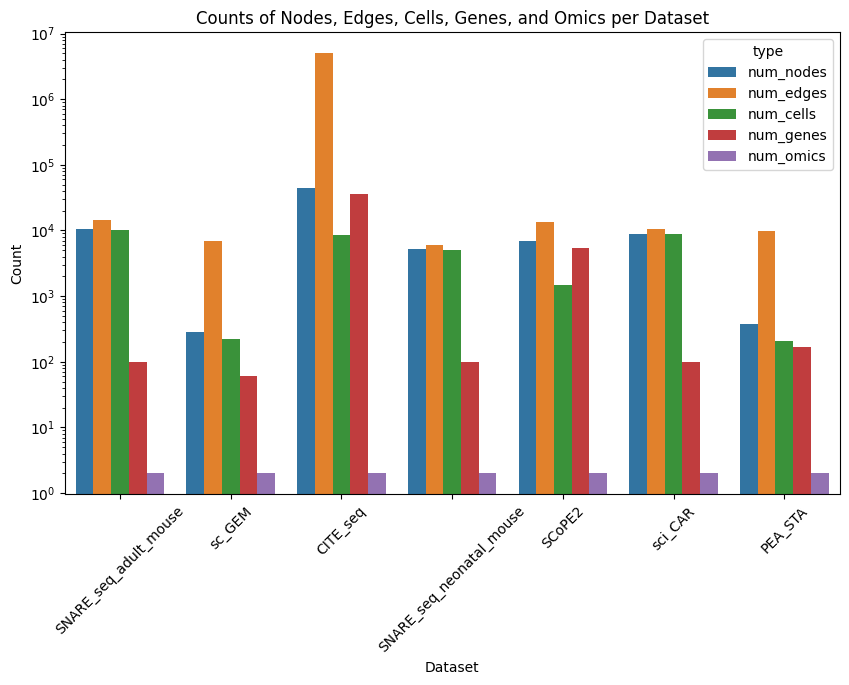

In [31]:
plt.figure(figsize=(10, 6))

sns.barplot(data=df_long, x='dataname', y='count', hue='type')
plt.yscale("log")
plt.xlabel("Dataset")
plt.ylabel("Count")
plt.title("Counts of Nodes, Edges, Cells, Genes, and Omics per Dataset")
plt.xticks(rotation=45)

In [32]:
g = load_graph(Path('./hypergraph/PEA_STA'))
print(g)

Load edges in 0.01 seconds.
Load nodes in 0.00 seconds.
Num nodes: 378, Num edges: 9977
Metadata: {'dataname': 'PEA_STA', 'filter_edge': 'non-negative', 'num_cells': 210, 'num_genes': 166, 'num_omics': 2, 'num_nodes': 378, 'num_edges': 9977, 'omics_offset': 0, 'gene_offset': 2, 'cell_offset': 168, 'raw_data': {'expr': './data/PEA_STA/expression_data.csv', 'protein': './data/PEA_STA/protein_data.csv'}, 'cell_key': 'Cells '}
HyperGraph(num_nodes=378, num_edges=9977)


In [33]:
g = load_graph(Path('./hypergraph/sc_GEM'))
print(g)

Load edges in 0.00 seconds.
Load nodes in 0.00 seconds.
Num nodes: 287, Num edges: 6805
Metadata: {'dataname': 'sc_GEM', 'filter_edge': 'non-negative', 'num_cells': 224, 'num_genes': 61, 'num_omics': 2, 'num_nodes': 287, 'num_edges': 6805, 'omics_offset': 0, 'gene_offset': 2, 'cell_offset': 63, 'raw_data': {'expr': './data/sc_GEM/expression_data.csv', 'methy': './data/sc_GEM/methylation_data.csv'}, 'cell_key': 'Cell ID'}
HyperGraph(num_nodes=287, num_edges=6805)


In [34]:
g = load_graph(Path('./hypergraph/sc_GEM'))
print(g)

Load edges in 0.00 seconds.
Load nodes in 0.00 seconds.
Num nodes: 287, Num edges: 6805
Metadata: {'dataname': 'sc_GEM', 'filter_edge': 'non-negative', 'num_cells': 224, 'num_genes': 61, 'num_omics': 2, 'num_nodes': 287, 'num_edges': 6805, 'omics_offset': 0, 'gene_offset': 2, 'cell_offset': 63, 'raw_data': {'expr': './data/sc_GEM/expression_data.csv', 'methy': './data/sc_GEM/methylation_data.csv'}, 'cell_key': 'Cell ID'}
HyperGraph(num_nodes=287, num_edges=6805)


In [35]:
g = load_graph(Path('./hypergraph/sci_CAR'))
print(g)

Load edges in 0.01 seconds.
Load nodes in 0.01 seconds.
Num nodes: 8939, Num edges: 10358
Metadata: {'dataname': 'sci_CAR', 'filter_edge': '3-sigma', 'num_cells': 8837, 'num_genes': 100, 'num_omics': 2, 'num_nodes': 8939, 'num_edges': 10358, 'omics_offset': 0, 'gene_offset': 2, 'cell_offset': 102, 'raw_data': {'atac': './data/sci_CAR/ATAC_lsi.csv', 'rna': './data/sci_CAR/RNA_pca.csv'}, 'cell_key': 'Unnamed: 0'}
HyperGraph(num_nodes=8939, num_edges=10358)


In [36]:
g = load_graph(Path('./hypergraph/SCoPE2'))
print(g)

Load edges in 0.01 seconds.
Load nodes in 0.00 seconds.
Num nodes: 6806, Num edges: 13239
Metadata: {'dataname': 'SCoPE2', 'filter_edge': '3-sigma', 'num_cells': 1490, 'num_genes': 5314, 'num_omics': 2, 'num_nodes': 6806, 'num_edges': 13239, 'omics_offset': 0, 'gene_offset': 2, 'cell_offset': 5316, 'raw_data': {'expr': './data/SCoPE2/expression_data.csv', 'protein': './data/SCoPE2/protein_data.csv'}, 'cell_key': 'Unnamed: 0'}
HyperGraph(num_nodes=6806, num_edges=13239)


In [37]:
g = load_graph(Path('./hypergraph/sc_GEM'))
print(g)

Load edges in 0.00 seconds.
Load nodes in 0.00 seconds.
Num nodes: 287, Num edges: 6805
Metadata: {'dataname': 'sc_GEM', 'filter_edge': 'non-negative', 'num_cells': 224, 'num_genes': 61, 'num_omics': 2, 'num_nodes': 287, 'num_edges': 6805, 'omics_offset': 0, 'gene_offset': 2, 'cell_offset': 63, 'raw_data': {'expr': './data/sc_GEM/expression_data.csv', 'methy': './data/sc_GEM/methylation_data.csv'}, 'cell_key': 'Cell ID'}
HyperGraph(num_nodes=287, num_edges=6805)


In [38]:
g = load_graph(Path('./hypergraph/SNARE_seq_adult_mouse'))
print(g)

Load edges in 0.00 seconds.
Load nodes in 0.01 seconds.
Num nodes: 10411, Num edges: 14504
Metadata: {'dataname': 'SNARE_seq_adult_mouse', 'filter_edge': '3-sigma', 'num_cells': 10309, 'num_genes': 100, 'num_omics': 2, 'num_nodes': 10411, 'num_edges': 14504, 'omics_offset': 0, 'gene_offset': 2, 'cell_offset': 102, 'raw_data': {'atac': './data/SNARE_seq_adult_mouse/ATAC_lsi.csv', 'rna': './data/SNARE_seq_adult_mouse/RNA_pca.csv'}, 'cell_key': 'Unnamed: 0'}
HyperGraph(num_nodes=10411, num_edges=14504)


In [39]:
g = load_graph(Path('./hypergraph/SNARE_seq_neonatal_mouse'))
print(g)

Load edges in 0.00 seconds.
Load nodes in 0.00 seconds.
Num nodes: 5183, Num edges: 5915
Metadata: {'dataname': 'SNARE_seq_neonatal_mouse', 'filter_edge': '3-sigma', 'num_cells': 5081, 'num_genes': 100, 'num_omics': 2, 'num_nodes': 5183, 'num_edges': 5915, 'omics_offset': 0, 'gene_offset': 2, 'cell_offset': 102, 'raw_data': {'atac': './data/SNARE_seq_neonatal_mouse/ATAC_lsi.csv', 'rna': './data/SNARE_seq_neonatal_mouse/RNA_pca.csv'}, 'cell_key': 'Unnamed: 0'}
HyperGraph(num_nodes=5183, num_edges=5915)


In [40]:
g = load_graph(Path('./hypergraph/CITE_seq'))
print(g)

Load edges in 0.09 seconds.
Load nodes in 0.04 seconds.
Num nodes: 44912, Num edges: 4993779
Metadata: {'dataname': 'CITE_seq', 'filter_edge': '3-sigma', 'num_cells': 8617, 'num_genes': 36293, 'num_omics': 2, 'num_nodes': 44912, 'num_edges': 4993779, 'omics_offset': 0, 'gene_offset': 2, 'cell_offset': 36295, 'raw_data': {'expr': './data/CITE_seq/expression_data.csv', 'protein': './data/CITE_seq/protein_data.csv'}, 'cell_key': 'cell ID'}
HyperGraph(num_nodes=44912, num_edges=4993779)
